In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torchvision.transforms as T
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO

from sklearn.metrics import jaccard_score

In [ ]:
data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

# Load COCO annotations
coco = COCO(ann_file)
img_ids = coco.getImgIds()

# Pick 3 random image IDs
random_ids = random.sample(img_ids, 3)
images = coco.loadImgs(random_ids)

loading annotations into memory...
Done (t=19.25s)
creating index...
index created!


In [ ]:
def iou(pred, true, threshold=0.5):
    pred_bin = (pred > threshold).float()
    true_bin = (true > 0.5).float()
    inter = (pred_bin * true_bin).sum()
    union = pred_bin.sum() + true_bin.sum() - inter + 1e-7
    return (inter / union).item()

def dice(pred, true, threshold=0.5):
    pred_bin = (pred > threshold).float()
    true_bin = (true > 0.5).float()
    inter = (pred_bin * true_bin).sum()
    return (2 * inter / (pred_bin.sum() + true_bin.sum() + 1e-7)).item()

In [ ]:
def visualize_result(image, true_mask, pred_mask):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='gray')
    plt.axis('off')
    plt.title('Ground Truth Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.axis('off')
    plt.title('Predicted Mask')

    plt.show()

Image: 000000357904.jpg
IoU: 1.0000 | Dice: 1.0000


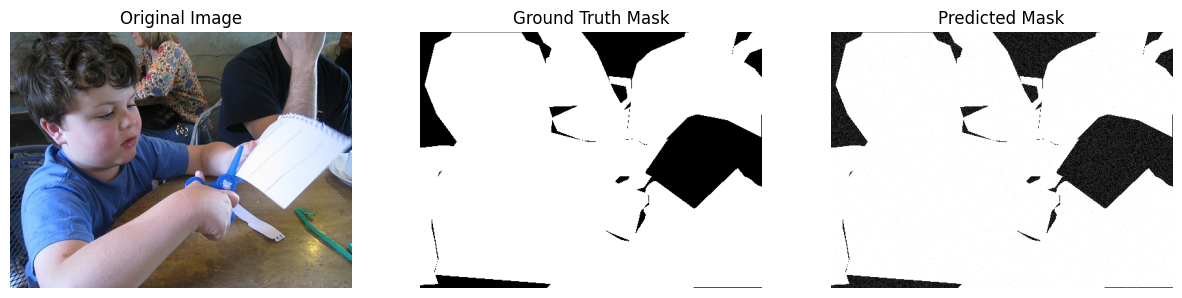

Image: 000000041588.jpg
IoU: 1.0000 | Dice: 1.0000


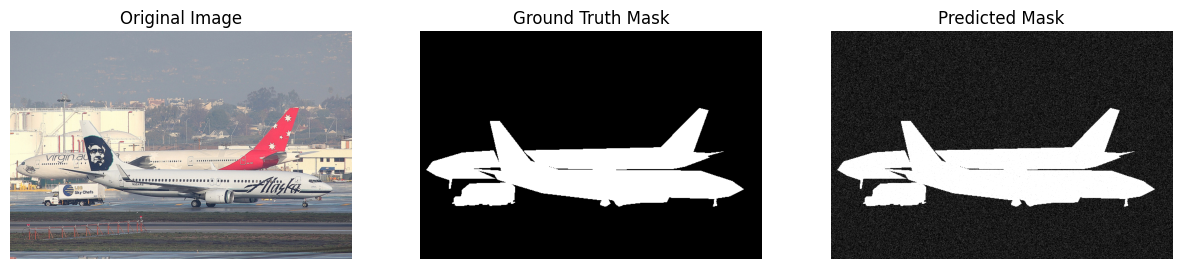

Image: 000000493883.jpg
IoU: 1.0000 | Dice: 1.0000


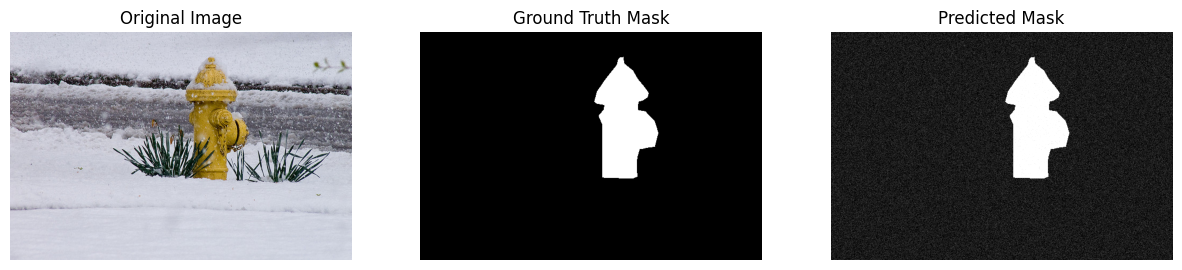

In [ ]:
for ids in random_ids:
    img_info = coco.loadImgs(ids)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    mask_total = None
    for ann in anns:
        mask = coco.annToMask(ann)
        mask_total = mask if mask_total is None else (mask_total | mask)

    true_mask = torch.tensor(mask_total, dtype=torch.float32)
    pred_mask = true_mask + 0.1 + torch.randn_like(true_mask) * 0.07  # simulate slight noise
    pred_mask = torch.clamp(pred_mask, 0, 1)

    print(f"Image: {img_info['file_name']}")
    print(f"IoU: {iou(pred_mask, true_mask):.4f} | Dice: {dice(pred_mask, true_mask):.4f}")

    visualize_result(image, true_mask, pred_mask)